In [2]:
from typing import TypedDict
from langgraph.graph import StateGraph

In [3]:
class PCAAgentState(TypedDict):
    """State of the PCA agent."""
    name : str

def Personal_compliment_agent(state: PCAAgentState) -> PCAAgentState:
    """Personal Compliment Agent that generates a compliment based on the user's name."""
    
    state['name'] = state['name'] + "you are doing an amazing job learning Langgraph!"

    return state



In [9]:
graph = StateGraph(PCAAgentState)
graph.add_node("Personal Compliment Agent",Personal_compliment_agent)
graph.set_entry_point("Personal Compliment Agent")
graph.set_finish_point("Personal Compliment Agent")

app = graph.compile()

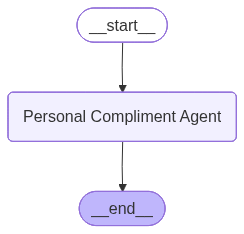

In [13]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [15]:
result = app.invoke({"name": "Bob, "})

In [16]:
result["name"]

'Bob, you are doing an amazing job learning Langgraph!'

SAMPLE 2

In [4]:
from typing import TypedDict, List
from langgraph.graph import StateGraph

In [5]:
class AgentState(TypedDict):
    values : List[int]
    name : str
    result : str

In [6]:
def process_values(state: AgentState) -> AgentState:
    """This process handles multiple different values."""
    
    state['result'] = f"Hi there {state['name']}, the sum of your values is: {sum(state['values'])}"

    return state

In [8]:
graph = StateGraph(AgentState)

graph.add_node("Process Values", process_values)
graph.set_entry_point("Process Values")
graph.set_finish_point("Process Values")

app = graph.compile()

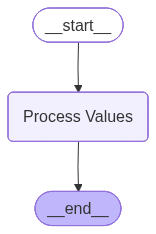

In [9]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [10]:
answers = app.invoke({"values": [1,2,3,4], "name": "Steve" })

In [11]:
answers["result"]

'Hi there Steve, the sum of your values is: 10'

SAMPLE 3

In [12]:
from typing import TypedDict, List
from langgraph.graph import StateGraph

In [16]:
class AgentState(TypedDict):
    name : str
    values : List[int]
    operation : str
    result : str

def process_values(state: AgentState) -> AgentState:
    """This process handles multiple different values."""
    
    if state['operation'] == "+":
        state['result'] = f"Hi {state['name']}, your sumis: {sum(state['values'])}"
    elif state['operation'] == "*":
        product = 1
        for value in state['values']:
            product *= value
        state['result'] = f"Hi there {state['name']}, the product of your values is: {product}"
    else:
        state['result'] = f"Hi there {state['name']}, the operation '{state['operation']}' is not supported."

    return state

In [20]:
graph = StateGraph(AgentState)
graph.add_node("Process Values", process_values)
graph.set_entry_point("Process Values")
graph.set_finish_point("Process Values")    

app = graph.compile()

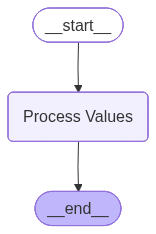

In [21]:
from IPython.display import Image, display
display(Image(answer.get_graph().draw_mermaid_png()))

In [22]:
answer = app.invoke({"name": "Jack Sparrow", "values": [1, 2, 3, 4], "operation": "*"})

In [24]:
answer['result']

'Hi there Jack Sparrow, the product of your values is: 24'

MULTIPLE NODES

In [26]:
from typing import TypedDict
from langgraph.graph import StateGraph

In [ ]:
class AgentState(TypedDict):
    name : str
    age : str
    skills : List[str]
    final : str

In [58]:
def first_node(state: AgentState) -> AgentState:
    """First node in the graph."""

    state['final'] = f"{state['name']}, welcome to the system!"
    return state

def second_node(state: AgentState) -> AgentState:
    """Second node in the graph."""
    
    state['final'] += f" You are {state['age']} years old!"
    
    return state

def third_node(state: AgentState) -> AgentState:
    """Third node in the graph."""
    state['final'] += f" You have skills in: "
    for value in state['skills']:
        if value == state['skills'][-1]:
            state['final'] += f"and {value}."
        else:
            state['final'] += f"{value}, "
    
    return state

In [59]:
graph = StateGraph(AgentState)
graph.add_node("Node 1", first_node)
graph.add_node("Node 2", second_node)
graph.add_node("Node 3", third_node)
graph.set_entry_point("Node 1")
graph.set_finish_point("Node 2")
graph.add_edge("Node 1", "Node 2")
graph.add_edge("Node 2", "Node 3")

app = graph.compile()

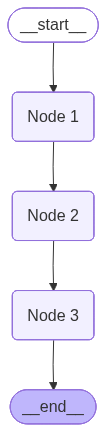

In [55]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [60]:
result =app.invoke({"name": "Linda", "age": "31", "skills": ["Python", "Machine Learning", "Langgraph"]})

In [61]:
result["final"]

'Linda, welcome to the system! You are 31 years old! You have skills in: Python, Machine Learning, and Langgraph.'

CONDITIONAL GRAPH

In [75]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [76]:
class AgentState(TypedDict):
    number1: int
    operation: str
    number2: int
    finalnumber: int

In [81]:
def adder(state: AgentState) -> AgentState:
    """This process handles multiple different values."""
    state['finalnumber'] = state['number1'] + state['number2']
    return state

def subtractor(state: AgentState) -> AgentState:
    """This process handles multiple different values."""
    state['finalnumber'] = state['number1'] - state['number2']
    return state

def decider(state: AgentState) -> AgentState:
    """This process handles multiple different values."""
    if state['operation'] == "+":
        return "addition_operation"
    elif state['operation'] == "-":
        return "subtraction_operation"
    else:
        raise ValueError(f"Operation {state['operation']} not supported.")

In [82]:
graph = StateGraph(AgentState)
graph.add_node("add_node", adder)
graph.add_node("subtract_node", subtractor)
graph.add_node("decider_node", lambda state:state)
graph.add_edge(START, "decider_node")
graph.add_conditional_edges(
    "decider_node",
    decider,
    {
        # Edges:node
        "addition_operation": "add_node",
        "subtraction_operation": "subtract_node"
    }
)
graph.add_edge("add_node", END)
graph.add_edge("subtract_node", END)

app = graph.compile()

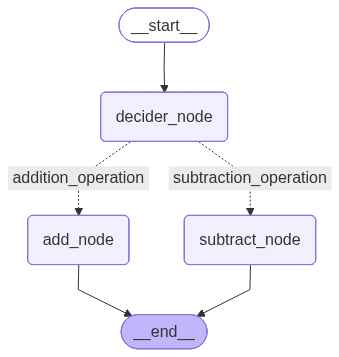

In [79]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [83]:
initial_state_1 = AgentState(number1= 10, operation = "+", number2 = 5)
print(app.invoke(initial_state_1))

{'number1': 10, 'operation': '+', 'number2': 5, 'finalnumber': 15}


CONDITIONAL GRAPH 2

In [84]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [85]:
class AgentState(TypedDict):
    number1: int
    operation1: str
    number2: int
    number3: int
    operation2: str
    number4: int
    finalnumber1: int
    finalnumber2: int

In [87]:
def adder1(state: AgentState) -> AgentState:
    """This process handles multiple different values."""
    state['finalnumber1'] = state['number1'] + state['number2']
    return state

def adder2(state: AgentState) -> AgentState:
    """This process handles multiple different values."""
    state['finalnumber2'] = state['number3'] + state['number4']
    return state

def subtractor1(state: AgentState) -> AgentState:
    """This process handles multiple different values."""
    state['finalnumber1'] = state['number1'] - state['number2']
    return state

def subtractor2(state: AgentState) -> AgentState:
    """This process handles multiple different values."""
    state['finalnumber2'] = state['number3'] - state['number4']
    return state

def decider1(state: AgentState) -> AgentState:
    """This process handles multiple different values."""
    if state['operation1'] == "+":
        return "addition_operation"
    elif state['operation1'] == "-":
        return "subtraction_operation"
    else:
        raise ValueError(f"Operation {state['operation1']} not supported.")

def decider2(state: AgentState) -> AgentState:
    """This process handles multiple different values."""
    if state['operation2'] == "+":
        return "addition_operation2"
    elif state['operation2'] == "-":
        return "subtraction_operation2"
    else:
        raise ValueError(f"Operation {state['operation2']} not supported.")

In [89]:
graph = StateGraph(AgentState)
graph.add_node("add_node", adder1)
graph.add_node("add_node2", adder2)
graph.add_node("subtract_node", subtractor1)
graph.add_node("subtract_node2", subtractor2)
graph.add_node("router", lambda state:state)
graph.add_node("router2", lambda state:state)
graph.add_edge(START, "router")
graph.add_conditional_edges(
    "router",
    decider1,
    {
        "addition_operation": "add_node",
        "subtraction_operation": "subtract_node"
    }
)
graph.add_edge("add_node", "router2")
graph.add_edge("subtract_node", "router2")
graph.add_conditional_edges(
    "router2",
    decider2,
    {
        "addition_operation2": "add_node2",
        "subtraction_operation2": "subtract_node2"
    }
)
graph.add_edge("add_node2", END)
graph.add_edge("subtract_node2", END)

app = graph.compile()

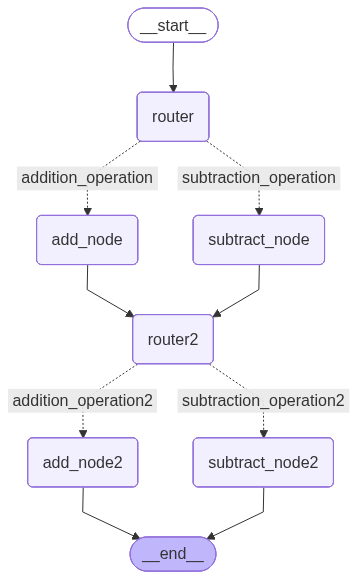

In [90]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [91]:
initial_state_1 = AgentState(number1= 10, operation1 = "+", number2 = 5, number3 = 20, operation2 = "-", number4 = 10)
print(app.invoke(initial_state_1))

{'number1': 10, 'operation1': '+', 'number2': 5, 'number3': 20, 'operation2': '-', 'number4': 10, 'finalnumber1': 15, 'finalnumber2': 10}


GRAPH V

In [92]:
from typing import TypedDict
import random
from langgraph.graph import StateGraph, START, END

In [93]:
class AgentState(TypedDict):
    name: str
    number: List[int]
    counter: int

In [94]:
def greeting_node(state: AgentState) -> AgentState:
    """This process handles multiple different values."""
    state['name'] = f"Hi there, {state['name']}."
    state['counter'] = 0

    return state

In [98]:
def random_node(state: AgentState) -> AgentState:
    """This generates random multiple numbers."""
    state['number'].append(random.randint(1, 100))
    state['counter'] += 1

    return state

def should_continue(state: AgentState) -> AgentState:
    """This process decides whether to continue or not."""
    if state['counter'] < 5:
        print(f"Entering loop {state['counter']}, continuing...")
        return "loop"
    else:
        return "exit"


In [99]:
# START -> greeting -> random no1 -> random no2 -> random no3 -> random no4 -> random no5 -> END
graph = StateGraph(AgentState)
graph.add_node("greeting", greeting_node)
graph.add_node("random", random_node)
graph.add_edge(START, "greeting")
graph.add_edge("greeting", "random")

graph.add_conditional_edges(
    "random",
    should_continue,
    {
        "loop": "random",
        "exit": END
    }
)
app = graph.compile()

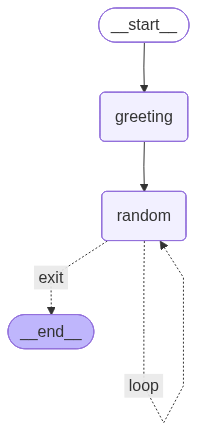

In [100]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [101]:
app.invoke({"name": "Alice", "number": [], "counter": -1})

Entering loop 1, continuing...
Entering loop 2, continuing...
Entering loop 3, continuing...
Entering loop 4, continuing...


{'name': 'Hi there, Alice.', 'number': [70, 86, 37, 35, 4], 'counter': 5}

GRAPH V 2

In [132]:
from typing import TypedDict
import random
from langgraph.graph import StateGraph, START, END

In [133]:
class AgentState(TypedDict):
    player_name: str
    target: int
    guesses: List[int]
    attempts: int
    lower_bound: int
    upper_bound: int

In [134]:
def setup(state: AgentState) -> AgentState:
    """Sets up the game: pick a secret target and reset counters."""
    state['target'] = random.randint(state['lower_bound'], state['upper_bound'])
    state['attempts'] = 0
    state['guesses'] = []
    return state

In [135]:
def guess_number(state: AgentState) -> AgentState:
    """Guess a random number within the current bounds. Returns state."""
    guess = random.randint(state['lower_bound'], state['upper_bound'])
    state['guesses'].append(guess)
    state['attempts'] += 1
    print(f"{state['player_name']} guessed {guess}.")
    return state

def hint_node(state: AgentState) -> AgentState:
    """Compare the last guess to the target and narrow the bounds. Returns state."""
    last_guess = state['guesses'][-1]
    target = state['target']
    if last_guess < target:
        state['lower_bound'] = last_guess + 1
        print(f"{state['player_name']}, your guess of {last_guess} is too low.")
    elif last_guess > target:
        state['upper_bound'] = last_guess - 1
        print(f"{state['player_name']}, your guess of {last_guess} is too high.")
    else:
        print(f"{state['player_name']}, congratulations! "
              f"You've guessed the correct number: {last_guess}.")
    return state

def should_continue(state: AgentState) -> str:
    """Router: decide whether to guess again or stop. Returns a string key."""
    if state['guesses'][-1] == state['target']:
        return "end"
    if state['attempts'] >= 7:
        print(f"Out of attempts! The number was {state['target']}.")
        return "end"
    return "continue"

In [136]:
graph = StateGraph(AgentState)
graph.add_node("setup", setup)
graph.add_node("guess", guess_number)
graph.add_node("hint_node", hint_node)
graph.add_edge(START, "setup")
graph.add_edge("setup", "guess")
graph.add_edge("guess", "hint_node")
graph.add_conditional_edges(
    "hint_node",
    should_continue,
    {
        "continue": "guess",
        "end": END
    }
)
app = graph.compile()

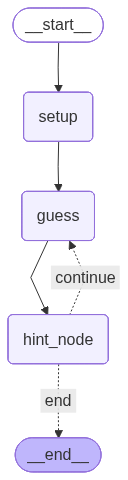

In [137]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [138]:
data = AgentState(player_name="Student", guesses=[], attempts=-1, lower_bound=1, upper_bound=20)
print(app.invoke(data))

Student guessed 13.
Student, your guess of 13 is too high.
Student guessed 4.
Student, congratulations! You've guessed the correct number: 4.
{'player_name': 'Student', 'target': 4, 'guesses': [13, 4], 'attempts': 2, 'lower_bound': 1, 'upper_bound': 12}
